# Feature extraction and spatial analysis

This notebook demonstrates a powerful, annotation-free workflow for analyzing the morphological landscape of a Whole Slide Image (WSI). The core idea is to leverage a pre-trained deep learning model to automatically extract meaningful features from image tiles and then use standard clustering tools to cluster and visualize these features.

The process involves three main steps:

- Tiling.
- Feature Extraction: A pre-trained vision model is used to process each tile. The model converts the visual information of each patch into a high-dimensional feature vector—a numerical signature that represents its content.
- Downstream Analysis: These feature vectors are then analyzed using a pipeline common in single-cell genomics. We will perform dimensionality reduction with PCA, build a neighborhood graph, and then use UMAP for visualization and the Leiden algorithm for clustering.

By the end of this workflow, we will have generated a UMAP embedding that visually organizes the tiles by similarity and a clustered map of the tiles of the WSI, effectively segmenting the tissue into distinct morphological regions without any manual intervention.

First, we will load a GTEx Small Intestine slide as example.

In [1]:
from huggingface_hub import hf_hub_download

slide = hf_hub_download(
    "rendeirolab/lazyslide-data",
    "GTEX-11DXX-1626.svs",
    repo_type="dataset",
)

In [2]:
!pip install wsidata

In [3]:
import sys
if 'lazyslide' not in sys.modules:
  !pip install lazyslide
from wsidata import open_wsi
import lazyslide as zs

Let's open the wsi!

WSI: /root/.cache/huggingface/hub/datasets--rendeirolab--lazyslide-data/snapshots/d469afd4a763ad366861e8c49d4cf424bfad902c/GTEX-11DXX-1626.svs
Reader: openslide
Dimensions: 38717×51791 (h×w), 3 Pyramids
Pixel physical size: 0.4942 MPP
SpatialData object
with coordinate systems:
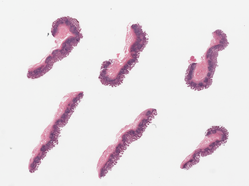

In [4]:
wsi = open_wsi(slide)
wsi

What does the tissue look like?

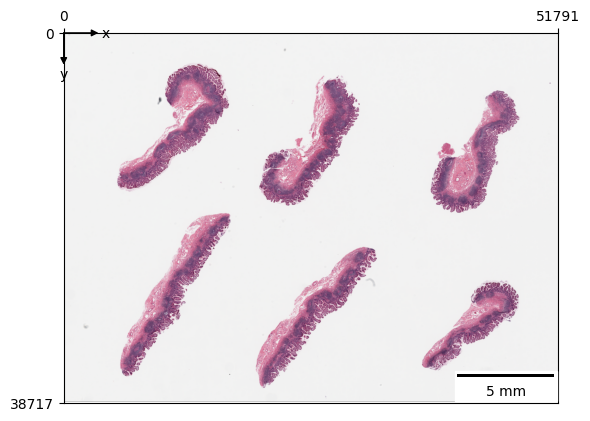

In [5]:
zs.pl.tissue(wsi)

Let's first find and tile the tissue, we will request tiny tile size of 128*128 px, this may take a while.

In [6]:
zs.pp.find_tissues(wsi)
zs.pp.tile_tissues(wsi, 224)

## Morphological feature extraction

Feature extraction is to transform the image into a the numeric representation, which comprises of different morphological features. Typically, this is done by feeding the tiles into a vision model.

LazySlide supports automatic mix-precision inference which may reduce memory usuage and have faster inference spped, try `amp=True`. Since we are working on a big slide with tiny tile sizes, this may take 10mins to finish (MacBook M3 Max).

```python
zs.tl.feature_extraction(wsi, "plip", amp=True)
```

::{note}
Autocast doesn't work well with mps backend though, you may get all nan results.

In [7]:
zs.tl.feature_extraction(wsi, "plip")

/usr/local/lib/python3.12/dist-packages/lazyslide_models/multimodal/plip.py:27: UserWarning: As from v0.8.2, Normalization will not be applied to image embedding of PLIP model anymore.A `normalize=True` argument is added to the `text_image_similarity` method.If you only use the image embedding for text image similarity, you can safely ignore this warning.
  warnings.warn(


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Output()

Features are saved as `AnnData` store with a convention of "{model name}_{tiles key}". For example, `h0-mini_tiles`

## Feature aggregation

To perform analysis across dataset, a usual way is to pool features into a 1D vector that can represent the entire slide. By default, the mean pooling is applied. Advanced slide encoders will be introduced later.

In [8]:
zs.tl.feature_aggregation(wsi, feature_key="plip")

You can retrieve specific feature with the `fetch` accessor. This will return a copy of the anndata.

In [9]:
adata = wsi.fetch.features_anndata("plip")

## Pre-computed results

If you don't want to run feature extraction, you can simply load the pre-computed one

In [10]:
wsi = zs.datasets.gtex_small_intestine()

WSI: /root/.cache/huggingface/hub/datasets--RendeiroLab--LazySlide-data/snapshots/d469afd4a763ad366861e8c49d4cf424bfad902c/GTEX-11DXX-1626.svs
Reader: openslide
Dimensions: 38717×51791 (h×w), 3 Pyramids
Pixel physical size: 0.4942 MPP
SpatialData object, with associated Zarr store: /root/.cache/huggingface/hub/datasets--RendeiroLab--LazySlide-data/snapshots/d469afd4a763ad366861e8c49d4cf424bfad902c/GTEX-11DXX-1626.zarr
├── Shapes
│     ├── 'tiles': GeoDataFrame shape: (19038, 3) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (6, 2) (2D shapes)
└── Tables
      ├── 'plip_tiles': AnnData (19038, 512)
      └── 'plip_tiles_text_similarity': AnnData (19038, 4)
with coordinate systems:
    ▸ 'global', with elements:
        tiles (Shapes), tissues (Shapes)
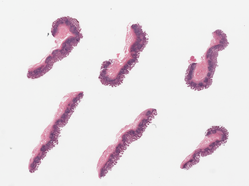

In [13]:
wsi

## Examination of feature space

You may need to install `scanpy` and `igraph` to run the following command.

This code takes the deep-learning feature data from image tiles we have extracted from PLIP, preprocesses it, and then performs a standard analysis workflow to identify groups of similar tiles (clustering). We can visualize the tile space using UMAP. The colors represent the different clusters, as found by computing Leiden clustering on the neighborhood graph of tiles.

In [12]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 133.5 MB/s eta 0:00:00


In [13]:
!pip install scanpy
import scanpy as sc

adata = wsi["plip_tiles"]
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", resolution=0.2)

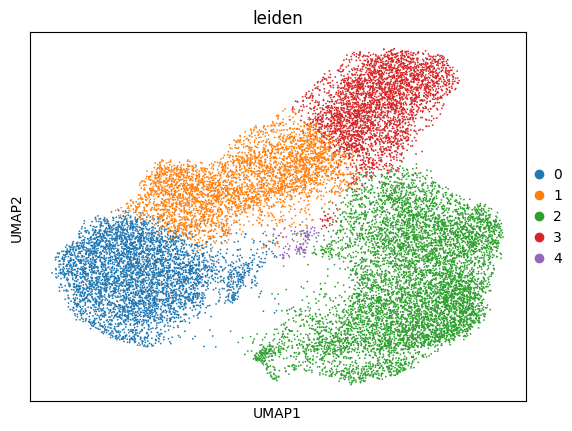

In [14]:
sc.pl.umap(adata, color="leiden")

In [15]:
sc.tl.rank_genes_groups(adata, groupby="leiden")

features = set()
for i in adata.obs["leiden"].unique():
    names = sc.get.rank_genes_groups_df(adata, i).names
    features.update(list(names[0:10]) + list(names[-10:]))
features = list(features)

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 8.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/marsilea/_deform.py:237: PerformanceWarning: Clustering large array (1770534 elements) with scipy. Install `fastcluster` for better performance: pip install marsilea[fast]
  dg = Dendrogram(row_data, linkage=self.row_linkage, **self.row_cluster_kws)


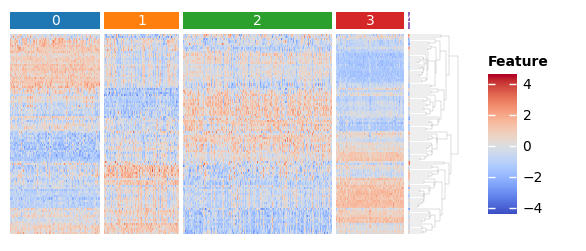

In [17]:
!pip install marsilea
import marsilea as ma
import marsilea.plotter as mp
from scipy.stats import zscore

key = "leiden"
h = ma.Heatmap(zscore(adata[:, features].X.T), height=2, width=4, label="Feature")
order = sorted(adata.obs[key].unique())
h.group_cols(adata.obs[key], order=order)
h.add_top(mp.Chunk(order, fill_colors=adata.uns[f"{key}_colors"], padding=2), pad=0.05)
h.add_dendrogram("right", method="average", linewidth=0.1)
h.add_legends()
h.render()

## Identification of spatial domains

The Leiden clustering on features from the foundational model can already recover the spatial domains of tissues pretty well. However, this clustering algorithm is based on the proximity of the morphological features of each tile, but it does not consider actual spatial information.

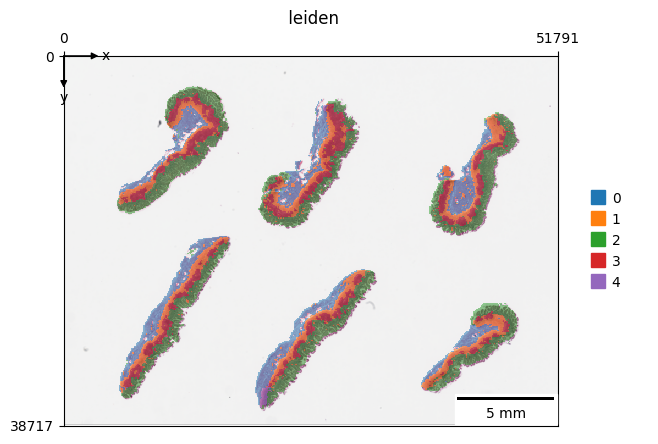

In [18]:
zs.pl.tiles(
    wsi,
    feature_key="plip",
    color="leiden",
    alpha=0.5,
    palette=adata.uns[f"{key}_colors"],
    show_contours=False,
)

For simplicity, you can run spatial domain analysis with `zs.tl.spatial_domain`. This is equivalent to the previous analysis.

In [19]:
zs.tl.spatial_domain(wsi, feature_key="plip", resolution=0.2)

In [20]:
wsi.write()

/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/usr/lib/python3.12/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(se

### Integration of spatial information with UTAG

In this example, you may notice the border of domain is not very smooth, this can be improved by integrating spatial information.

[UTAG](https://doi.org/10.1038/s41592-022-01657-2) is a method develop to discovery spatial domain with unsupervised learning.

The basic idea is to use message passing to combine the physical position of the tiles and the features of each tile to create a spatially-informed neighborhood graph. In the following code block, we first create an adjacency matrix of the tile locations with `zs.pp.tile_graph` and then integrate spatial tile context with vision features using spatial feature smoothing with `zs.tl.spatial_features`.

In [21]:
zs.pp.tile_graph(wsi)
zs.tl.spatial_features(wsi, "plip")

In [22]:
zs.tl.spatial_domain(wsi, layer="spatial_features", feature_key="plip", resolution=0.2)

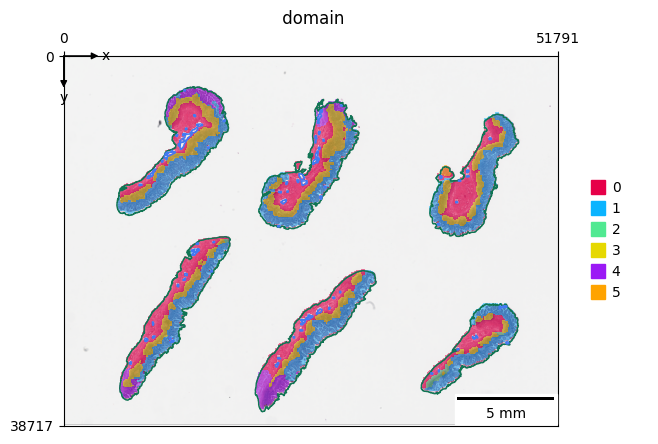

In [23]:
zs.pl.tiles(wsi, color="domain", alpha=0.5)

Now we can observe there are 6 domains in the tissues, with smooth borders.

## Text feature extraction

Apart from deriving morphological features from vision models, you can also run multimodal to derive text features.

Currently, there are two vision-language models for pathology
- [PLIP](https://doi.org/10.1038/s41591-023-02504-3), Nature Medicine, 2023
- [CONCH](https://doi.org/10.1038/s41591-024-02856-4), Nature Medicine, 2024

Since we've extracted the plip vision features for our WSI, we only need to extract features for the texts.



In [24]:
terms = ["mucosa", "submucosa", "musclaris", "lymphocyte"]

In [25]:
embeddings = zs.tl.text_embedding(terms, model="plip")
zs.tl.text_image_similarity(wsi, embeddings, model="plip", softmax=True)

/usr/local/lib/python3.12/dist-packages/lazyslide_models/multimodal/plip.py:27: UserWarning: As from v0.8.2, Normalization will not be applied to image embedding of PLIP model anymore.A `normalize=True` argument is added to the `text_image_similarity` method.If you only use the image embedding for text image similarity, you can safely ignore this warning.
  warnings.warn(


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lazyslide/tools/_text_annotate.py:162: UserWarning: As of v0.8.2, the image embedding from image text model is not normalized after feature extraction by default. The normalization is applied here (text_image_similarity),if your features are extracted in previous versions, consider setting normalize=False.
  warnings.warn(msg, stacklevel=find_stack_level())


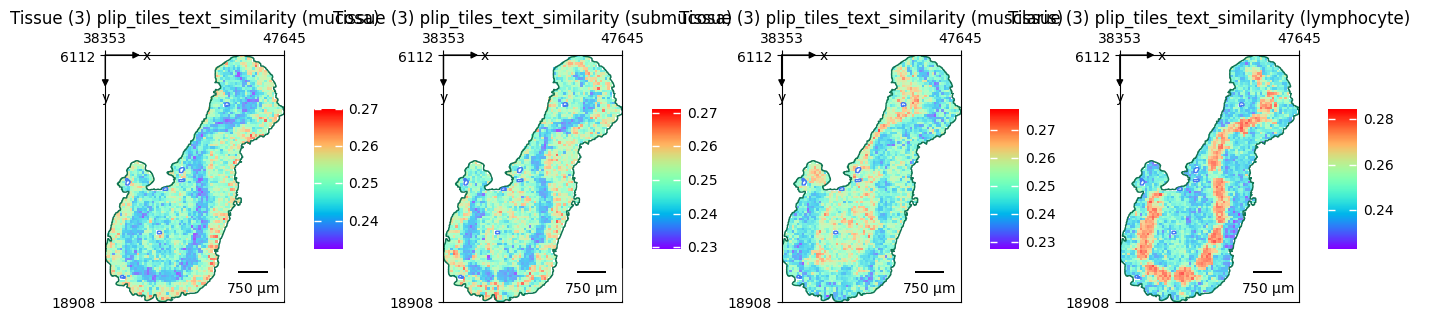

In [26]:
zs.pl.tiles(
    wsi,
    feature_key="plip_tiles_text_similarity",
    color=terms,
    cmap="rainbow",
    show_image=False,
    tissue_id=3,
    alpha=0.7,
)